
#Financial Transaction Validation at Scale with NVIDIA RAPIDS

Can we safely validate and govern AI-driven financial workflows at scale?


Before a single number appears on a dashboard or gets fed into a fraud detection system, financial data goes through a lot of pipelines. And if that data is carrying duplicates, missing fields, weird outliers, or suspicious patterns, everything downstream starts to crack. Risk models drift. Compliance workflows flag the wrong things. AI agents make decisions based on noise.
That's the problem this tutorial is built around.
We're going to walk through how to build a financial transaction validation workflow using NVIDIA RAPIDS and we've kept it beginner-friendly intentionally. You don't need to be a GPU expert to follow along.
Now, the obvious question is: why GPU? Yes, it's faster but speed alone isn't the point. What GPU-accelerated processing actually unlocks is the ability to work with much larger datasets, apply multiple governance rules in parallel, and produce outputs that downstream systems can actually rely on. Cleaner data. More trustworthy AI.
One important note before you dive in: everything here runs on synthetic data. No real customer records, no actual bank or merchant information, no real geographic risk signals. All of it is generated specifically so this workflow is safe to share, reproduce, and learn from openly.

# What You Will Build



In this notebook, you will build an end-to-end financial transaction validation workflow.

You will:

1. Generate a safe synthetic financial transaction dataset.
2. Add realistic data quality and risk-style issues.
3. Process the raw transaction data without validation.
4. Build a multi-layer validation layer.
5. Apply validation rules using Pandas on CPU.
6. Apply the same validation rules using RAPIDS cuDF on GPU.
7. Compare outputs with and without validation.
8. Compare CPU and GPU execution time.
9. Produce accepted, clean passed, warning, and rejected transaction outputs.
10. See how validation improves downstream AI or analytics summaries.

#Why This Matters

AI agents and financial automation systems depend on structured, reliable transaction data. When the data feeding into those systems is noisy, duplicated, incomplete, or suspicious, the outputs become unreliable too.
In financial services, a validation layer can act as a safety checkpoint before data ever reaches fraud monitoring systems, compliance workflows, payment operations dashboards, customer risk scoring pipelines, AI assistants and agentic workflows, or audit and reporting processes.
That's exactly what this notebook demonstrates.

#What Is RAPIDS?

RAPIDS is an open-source GPU-accelerated data science ecosystem from NVIDIA. It provides Python libraries that help data scientists and engineers run many common data processing and machine learning operations on NVIDIA GPUs.

For beginners, the simplest way to understand this notebook is:


*   Pandas processes DataFrames on the CPU.
cuDF processes DataFrames on the GPU and uses a Pandas-like API.
RAPIDS is the broader NVIDIA ecosystem that includes cuDF and other GPU-accelerated tools.
*  cuDF processes DataFrames on the GPU and uses a Pandas-like API.


*   RAPIDS is the broader NVIDIA ecosystem that includes cuDF and other GPU-accelerated tools.

In this first version, the main RAPIDS library used is cuDF, because transaction validation is mostly a DataFrame workload: filtering rows, checking missing values, detecting duplicates, grouping records, and creating summary reports.

Future extensions could add:

* cuML for anomaly detection or clustering,

*   cuGraph for relationship analysis,
*   Dask-cuDF for larger-than-memory or distributed workflows.



##Notebook Design Principle

This tutorial is written for beginners first.

Each section explains:

What we are doing.

1.   What we are doing.
2.  Why it matters.
3. How RAPIDS fits into the workflow.
4. What output we get from the step.

The goal is that a student, analyst, or engineer who is new to RAPIDS can still follow the full workflow.

## End-to-End Workflow

The notebook demonstrates where RAPIDS cuDF fits within a financial validation pipeline. Rather than focusing only on benchmarking, the goal is to show how GPU-accelerated validation can become part of a larger AI or financial workflow.

```text
                Financial Transactions
               or AI-Generated Signals
                          │
                          ▼
               Structured DataFrame
                          │
                          ▼
            Rule-Based Validation Logic
                          │
             ┌────────────┴────────────┐
             │                         │
             ▼                         ▼
       Pandas (CPU)             RAPIDS cuDF (GPU)
             │                         │
             └────────────┬────────────┘
                          ▼
          Compare Performance & Results
                          │
                          ▼
          ALLOW / BLOCK / REVIEW Decisions
                          │
                          ▼
           Downstream Financial Systems
   (Dashboards • Fraud Detection • Compliance • AI)
```

**Key idea**

The business problem remains the same regardless of implementation. This notebook demonstrates two implementations of the same validation logic—Pandas on the CPU and RAPIDS cuDF on the GPU—and compares their performance while producing identical validation decisions.

## Notebook:

# Financial Transaction Validation at Scale with NVIDIA RAPIDS

Can we safely validate and govern AI-driven financial workflows at scale?

In this notebook, we build a beginner-friendly financial transaction validation workflow using NVIDIA RAPIDS. We will create synthetic transaction data, intentionally add realistic data quality and risk-style issues, apply a validation layer, and compare outputs with and without validation.

The speedup is not the main story. The main story is what the speedup allows us to do: validate more financial data, apply more governance rules, and produce cleaner outputs for downstream AI and analytics workflows.

## Why Transaction Validation Matters

Before transaction data reaches a dashboard, fraud model, compliance workflow, or AI agent, it should be checked for quality and risk signals.

Without validation, downstream systems may use records that are duplicated, incomplete, invalid, or suspicious. That can lead to incorrect summaries, noisy risk signals, or unreliable AI-generated explanations.

In this notebook, we will build a validation layer that separates transaction records into four groups:

1. **Accepted transactions** — records that passed hard validation checks. These may still include warning-level records.
2. **Clean passed transactions** — accepted records with no warning flags.
3. **Warning transactions** — accepted records that should be reviewed because they contain risk-style signals.
4. **Rejected transactions** — records with hard failures, such as invalid amount, missing required fields, unsupported currency, duplicate transaction ID, or unsupported payment channel.

Environment Check:

In [ ]:
import sys
import platform
import subprocess

print("Python version:", sys.version)
print("Platform:", platform.platform())

try:
    import cudf
    RAPIDS_AVAILABLE = True
    print("cuDF is available.")
    print("cuDF version:", cudf.__version__)
except ImportError:
    RAPIDS_AVAILABLE = False
    print("cuDF is not currently available in this runtime.")
    print("If you are using Google Colab, switch to a GPU runtime and use the current RAPIDS installation guidance for Colab.")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
cuDF is available.
cuDF version: 26.02.01


Imports:

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cudf
    RAPIDS_AVAILABLE = True
except ImportError:
    RAPIDS_AVAILABLE = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Synthetic Data Explanation Markdown


## Step 1: Generate Synthetic Financial Transaction Data

This notebook uses synthetic data by design.

That is important because open-source examples should be safe, reproducible, and easy for anyone to run. We do not use real customer records, bank data, merchant data, sanctions data, or country-level risk labels.

Instead, we create neutral synthetic risk fields such as:

- `geo_risk_score`
- `merchant_risk_score`
- `device_trust_score`
- `velocity_risk_flag`

These fields let us demonstrate validation logic without assigning risk to real countries, people, companies, or regions.

# Generate Synthetic Transactions

In [ ]:
import numpy as np
import pandas as pd

def generate_synthetic_transactions(n_rows=1_000_000, random_seed=42):
    """
    Generate open-source-safe synthetic financial transaction data.

    This dataset does not contain real customer, bank, merchant, payment, or geographic risk data.
    All values are synthetic and created only for demonstrating a transaction validation workflow.
    """
    rng = np.random.default_rng(random_seed)

    customer_ids = rng.integers(10000, 99999, size=n_rows)
    merchant_ids = rng.integers(1000, 9999, size=n_rows).astype(object)
    transaction_amounts = rng.lognormal(mean=3.5, sigma=1.0, size=n_rows).round(2)

    currencies = rng.choice(
        ["USD", "EUR", "GBP", "INR", "CAD"],
        size=n_rows,
        p=[0.70, 0.08, 0.07, 0.10, 0.05],
    )

    payment_channels = rng.choice(
        ["card", "ach", "wire", "wallet"],
        size=n_rows,
        p=[0.65, 0.20, 0.05, 0.10],
    )

    merchant_categories = rng.choice(
        ["grocery", "fuel", "travel", "electronics", "subscription", "cash_advance"],
        size=n_rows,
        p=[0.30, 0.18, 0.12, 0.17, 0.18, 0.05],
    )

    device_ids = rng.integers(500000, 999999, size=n_rows)

    geo_risk_score = rng.choice(
        ["low", "medium", "high"],
        size=n_rows,
        p=[0.86, 0.11, 0.03],
    )


    merchant_risk_score = rng.choice(
        ["low", "medium", "high"],
        size=n_rows,
        p=[0.82, 0.14, 0.04],
    )

    device_trust_score = rng.choice(
        ["trusted", "unknown", "suspicious"],
        size=n_rows,
        p=[0.88, 0.09, 0.03],
    )

    base_time = pd.Timestamp("2026-01-01")
    random_minutes = rng.integers(0, 60 * 24 * 30, size=n_rows)
    timestamps = base_time + pd.to_timedelta(random_minutes, unit="m")

    df = pd.DataFrame({
        "transaction_id": np.arange(1, n_rows + 1),
        "customer_id": customer_ids,
        "merchant_id": merchant_ids,
        "transaction_amount": transaction_amounts,
        "currency": currencies,
        "transaction_timestamp": timestamps,
        "payment_channel": payment_channels,
        "merchant_category": merchant_categories,
        "device_id": device_ids,
        "geo_risk_score": geo_risk_score,
        "merchant_risk_score": merchant_risk_score,
        "device_trust_score": device_trust_score,
    })

    # Add a neutral synthetic velocity signal.
    # In real systems, this might be calculated from customer/device behavior over time.
    df["velocity_risk_flag"] = rng.choice(
        [False, True],
        size=n_rows,
        p=[0.96, 0.04],
    )

     # Inject realistic data quality issues.
    issue_count = max(1, n_rows // 200)

    missing_merchant_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[missing_merchant_idx, "merchant_id"] = None

    invalid_currency_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[invalid_currency_idx, "currency"] = "XXX"

    negative_amount_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[negative_amount_idx, "transaction_amount"] = -1 * df.loc[negative_amount_idx, "transaction_amount"]

    zero_amount_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[zero_amount_idx, "transaction_amount"] = 0

    high_amount_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[high_amount_idx, "transaction_amount"] = rng.uniform(10_000, 100_000, size=issue_count).round(2)

    invalid_payment_channel_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[invalid_payment_channel_idx, "payment_channel"] = "unsupported_channel"

    duplicate_idx = rng.choice(n_rows, size=issue_count, replace=False)
    duplicate_source_idx = rng.choice(n_rows, size=issue_count, replace=False)
    df.loc[duplicate_idx, "transaction_id"] = df.loc[duplicate_source_idx, "transaction_id"].to_numpy()

    return df
transactions_pd = generate_synthetic_transactions(n_rows=1_000_000, random_seed=42)
transactions_pd.head()

,transaction_id,customer_id,merchant_id,transaction_amount,currency,transaction_timestamp,payment_channel,merchant_category,device_id,geo_risk_score,merchant_risk_score,device_trust_score,velocity_risk_flag
0,1,18032,7642,2.60,EUR,2026-01-12 20:39:00,card,subscription,765113,low,low,trusted,False
1,2,79655,7990,27.70,USD,2026-01-11 18:34:00,ach,grocery,652796,low,high,unknown,False
2,3,68910,7658,33.10,USD,2026-01-16 16:43:00,wallet,subscription,818140,low,low,trusted,False
3,4,49498,4224,33.15,USD,2026-01-12 22:17:00,card,grocery,955134,low,low,unknown,False
4,5,48970,5261,47.06,GBP,2026-01-11 06:42:00,card,electronics,810954,low,low,trusted,False


# Raw Workflow Markdown

## Step 2: Process the Raw Data Without Validation

First, we look at what happens when the transaction feed is summarized without any validation layer.

This is the risky path. It may include duplicate transactions, invalid amounts, missing merchant IDs, invalid currencies, and warning-level risk signals.

This section gives us a baseline so we can later compare it against the validation-enabled workflow.

##Raw Summary Without Validation

In [ ]:
def raw_summary_pandas(df):
    """
    Create a simple summary from raw transaction data.

    This function intentionally does not validate the data first.
    It represents what can happen when downstream systems consume raw data directly.
    """
    return pd.DataFrame({
        "metric": [
            "row_count",
            "unique_transactions",
            "unique_customers",
            "total_transaction_amount",
            "average_transaction_amount",
            "unsupported_payment_channel_rows",
            "missing_merchant_ids",
            "invalid_currency_rows",
            "duplicate_transaction_rows",
            "non_positive_amount_rows",
        ],
        "value": [
            len(df),
            df["transaction_id"].nunique(),
            df["customer_id"].nunique(),
            round(float(df["transaction_amount"].sum()), 2),
            round(float(df["transaction_amount"].mean()), 2),
            int((~df["payment_channel"].isin(["card", "ach", "wire", "wallet"])).sum()),
            int(df["merchant_id"].isna().sum()),
            int((~df["currency"].isin(["USD", "EUR", "GBP", "INR", "CAD"])).sum()),
            int(df["transaction_id"].duplicated(keep=False).sum()),
            int((df["transaction_amount"] <= 0).sum()),
        ]
    })

raw_summary = raw_summary_pandas(transactions_pd)
raw_summary

,metric,value
0,row_count,1.000000e+06
1,unique_transactions,9.950320e+05
2,unique_customers,8.999600e+04
3,total_transaction_amount,3.273914e+08
4,average_transaction_amount,3.273900e+02
5,unsupported_payment_channel_rows,5.000000e+03
6,missing_merchant_ids,5.000000e+03
7,invalid_currency_rows,5.000000e+03
8,duplicate_transaction_rows,9.936000e+03
9,non_positive_amount_rows,9.923000e+03


#Validation Layer Explanation Markdown

## Step 3: Build a Multi-Layer Validation Layer

A validation layer checks transaction records before they are used by downstream systems.

In this notebook, we use two types of validation outcomes:

### Hard Failures
These records should be rejected from the clean dataset because they contain clear data quality problems.

Examples:

- missing required fields,
- invalid or non-positive transaction amount,
- unsupported currency,
- duplicate transaction ID,
- unsupported payment channel.

### Warnings
These records may still be valid transactions, but they should be flagged for review.

Examples:

- high transaction amount,
- high synthetic geo risk score,
- high synthetic merchant risk score,
- suspicious device trust score,
- velocity risk flag.

This design is closer to real-world financial workflows because not every risk signal means a transaction is invalid. Some records should be rejected, while others should be routed for review.

##Validation Constants

In [ ]:
ALLOWED_CURRENCIES = {"USD", "EUR", "GBP", "INR", "CAD"}
ALLOWED_PAYMENT_CHANNELS = {"card", "ach", "wire", "wallet"}
HIGH_AMOUNT_THRESHOLD = 10_000

HARD_FAIL_COLUMNS = [
    "missing_required_field",
    "invalid_amount",
    "invalid_currency",
    "duplicate_transaction_id",
    "invalid_payment_channel",
]

WARNING_COLUMNS = [
    "high_value_transaction",
    "high_geo_risk_score",
    "high_merchant_risk_score",
    "suspicious_device_trust_score",
    "velocity_risk_flag_detected",
]

## Pandas CPU Validation

In [ ]:
def validate_transactions_pandas(df):
    """
    Apply a multi-layer validation workflow using Pandas on CPU.

    This version is used as the CPU baseline.
    """
    result = df.copy()

    result["missing_required_field"] = (
        result["transaction_id"].isna()
        | result["customer_id"].isna()
        | result["merchant_id"].isna()
        | result["transaction_timestamp"].isna()
    )

    result["invalid_amount"] = result["transaction_amount"] <= 0
    result["invalid_currency"] = ~result["currency"].isin(ALLOWED_CURRENCIES)
    result["duplicate_transaction_id"] = result["transaction_id"].duplicated(keep=False)
    result["invalid_payment_channel"] = ~result["payment_channel"].isin(ALLOWED_PAYMENT_CHANNELS)

    result["high_value_transaction"] = result["transaction_amount"] >= HIGH_AMOUNT_THRESHOLD
    result["high_geo_risk_score"] = result["geo_risk_score"] == "high"
    result["high_merchant_risk_score"] = result["merchant_risk_score"] == "high"
    result["suspicious_device_trust_score"] = result["device_trust_score"] == "suspicious"
    result["velocity_risk_flag_detected"] = result["velocity_risk_flag"] == True

    result["validation_failed"] = result[HARD_FAIL_COLUMNS].any(axis=1)
    result["validation_warning"] = result[WARNING_COLUMNS].any(axis=1)

    accepted = result[~result["validation_failed"]].copy()

    clean_passed = result[
        (~result["validation_failed"]) & (~result["validation_warning"])
    ].copy()

    warnings = result[
        (~result["validation_failed"]) & (result["validation_warning"])
    ].copy()

    rejected = result[result["validation_failed"]].copy()

    summary = pd.DataFrame({
        "metric": [
            "total_rows",
            "accepted_rows",
            "clean_passed_rows",
            "warning_rows",
            "rejected_rows",
        ] + HARD_FAIL_COLUMNS + WARNING_COLUMNS,
        "value": [
            len(result),
            len(accepted),
            len(clean_passed),
            len(warnings),
            len(rejected),
        ] + [int(result[col].sum()) for col in HARD_FAIL_COLUMNS + WARNING_COLUMNS]
    })

    return accepted, clean_passed, rejected, warnings, summary, result

##RAPIDS cuDF Validation

In [ ]:
def validate_transactions_cudf(df):
    """
    Apply the same multi-layer validation workflow using RAPIDS cuDF on GPU.

    This version uses GPU DataFrame operations and mirrors the Pandas validation logic.
    """
    result = df.copy()

    result["missing_required_field"] = (
        result["transaction_id"].isna()
        | result["customer_id"].isna()
        | result["merchant_id"].isna()
        | result["transaction_timestamp"].isna()
    )

    result["invalid_amount"] = result["transaction_amount"] <= 0
    result["invalid_currency"] = ~result["currency"].isin(list(ALLOWED_CURRENCIES))
    result["duplicate_transaction_id"] = result["transaction_id"].duplicated(keep=False)
    result["invalid_payment_channel"] = ~result["payment_channel"].isin(list(ALLOWED_PAYMENT_CHANNELS))

    result["high_value_transaction"] = result["transaction_amount"] >= HIGH_AMOUNT_THRESHOLD
    result["high_geo_risk_score"] = result["geo_risk_score"] == "high"
    result["high_merchant_risk_score"] = result["merchant_risk_score"] == "high"
    result["suspicious_device_trust_score"] = result["device_trust_score"] == "suspicious"
    result["velocity_risk_flag_detected"] = result["velocity_risk_flag"] == True

    result["validation_failed"] = result[HARD_FAIL_COLUMNS[0]]
    for col in HARD_FAIL_COLUMNS[1:]:
        result["validation_failed"] = result["validation_failed"] | result[col]

    result["validation_warning"] = result[WARNING_COLUMNS[0]]
    for col in WARNING_COLUMNS[1:]:
        result["validation_warning"] = result["validation_warning"] | result[col]

    accepted = result[~result["validation_failed"]]

    clean_passed = result[
        (~result["validation_failed"]) & (~result["validation_warning"])
    ]

    warnings = result[
        (~result["validation_failed"]) & (result["validation_warning"])
    ]

    rejected = result[result["validation_failed"]]

    metrics = [
        "total_rows",
        "accepted_rows",
        "clean_passed_rows",
        "warning_rows",
        "rejected_rows",
    ] + HARD_FAIL_COLUMNS + WARNING_COLUMNS

    values = [
        len(result),
        len(accepted),
        len(clean_passed),
        len(warnings),
        len(rejected),
    ] + [int(result[col].sum()) for col in HARD_FAIL_COLUMNS + WARNING_COLUMNS]

    summary = cudf.DataFrame({"metric": metrics, "value": values})

    return accepted, clean_passed, rejected, warnings, summary, result

##Run Pandas CPU Validation

In [ ]:
import time
start = time.perf_counter()
accepted_pd, clean_passed_pd, rejected_pd, warnings_pd, summary_pd, validated_pd = validate_transactions_pandas(transactions_pd)
pandas_time = time.perf_counter() - start

print(f"Pandas CPU validation runtime: {pandas_time:.4f} seconds")
summary_pd

Pandas CPU validation runtime: 1.6569 seconds


,metric,value
0,total_rows,1000000
1,accepted_rows,965622
2,clean_passed_rows,832928
3,warning_rows,132694
4,rejected_rows,34378
5,missing_required_field,5000
6,invalid_amount,9923
7,invalid_currency,5000
8,duplicate_transaction_id,9936
9,invalid_payment_channel,5000


## Run RAPIDS cuDF GPU Validation

In [ ]:
import time

try:
    import cudf
    RAPIDS_AVAILABLE = True
except ImportError:
    RAPIDS_AVAILABLE = False

if RAPIDS_AVAILABLE:
    # Create a copy to avoid modifying the original transactions_pd for other uses
    transactions_pd_for_cudf = transactions_pd.copy()
    # Convert the 'merchant_id' column to string type to handle mixed integer/None objects
    # which causes MixedTypeError during cuDF conversion.
    if 'merchant_id' in transactions_pd_for_cudf.columns and transactions_pd_for_cudf['merchant_id'].dtype == 'object':
        transactions_pd_for_cudf['merchant_id'] = transactions_pd_for_cudf['merchant_id'].astype(str)

    transactions_gdf = cudf.from_pandas(transactions_pd_for_cudf)

    start = time.perf_counter()
    accepted_gdf, clean_passed_gdf, rejected_gdf, warnings_gdf, summary_gdf, validated_gdf = validate_transactions_cudf(transactions_gdf)
    cudf_time = time.perf_counter() - start

    print(f"RAPIDS cuDF GPU validation runtime: {cudf_time:.4f} seconds")
    display(summary_gdf.to_pandas())
else:
    cudf_time = None
    print("RAPIDS cuDF is not available in this runtime. Pandas results are still available.")

RAPIDS cuDF GPU validation runtime: 0.3552 seconds


,metric,value
0,total_rows,1000000
1,accepted_rows,970453
2,clean_passed_rows,837088
3,warning_rows,133365
4,rejected_rows,29547
5,missing_required_field,0
6,invalid_amount,9923
7,invalid_currency,5000
8,duplicate_transaction_id,9936
9,invalid_payment_channel,5000


#With vs Without Validation Markdown

## Step 4: Compare Outputs With and Without Validation

Now we compare the raw transaction feed against the validation-enabled output.

This is the most important part of the notebook.

The value of the validation layer is not only that it can run faster on a GPU. The value is that it improves the quality of the data before downstream systems use it.

##With vs Without Validation Summary

In [ ]:
comparison_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "total_transaction_amount",
        "average_transaction_amount",
        "unique_transactions",
        "accepted_rows",
        "clean_passed_rows",
        "warning_rows",
        "rejected_rows",
    ],
    "without_validation": [
        len(transactions_pd),
        round(float(transactions_pd["transaction_amount"].sum()), 2),
        round(float(transactions_pd["transaction_amount"].mean()), 2),
        transactions_pd["transaction_id"].nunique(),
        "not separated",
        "not separated",
        "not separated",
        "not separated",
    ],
    "with_validation": [
        len(accepted_pd),
        round(float(accepted_pd["transaction_amount"].sum()), 2),
        round(float(accepted_pd["transaction_amount"].mean()), 2),
        accepted_pd["transaction_id"].nunique(),
        len(accepted_pd),
        len(clean_passed_pd),
        len(warnings_pd),
        len(rejected_pd),
    ]
})

comparison_summary

,metric,without_validation,with_validation
0,row_count,1000000,9.656220e+05
1,total_transaction_amount,327391412.5,3.199350e+08
2,average_transaction_amount,327.39,3.313300e+02
3,unique_transactions,995032,9.656220e+05
4,accepted_rows,not separated,9.656220e+05
5,clean_passed_rows,not separated,8.329280e+05
6,warning_rows,not separated,1.326940e+05
7,rejected_rows,not separated,3.437800e+04


# Runtime Comparison

In [ ]:
runtime_rows = [{"engine": "Pandas CPU", "runtime_seconds": pandas_time}]

if cudf_time is not None:
    runtime_rows.append({"engine": "RAPIDS cuDF GPU", "runtime_seconds": cudf_time})

runtime_comparison = pd.DataFrame(runtime_rows)
runtime_comparison

,engine,runtime_seconds
0,Pandas CPU,1.656877
1,RAPIDS cuDF GPU,0.355213


## Runtime Comparison

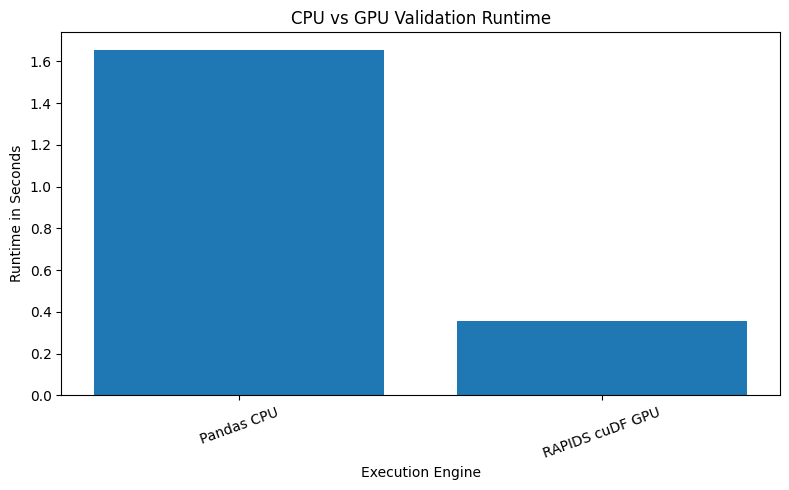

In [ ]:
import matplotlib.pyplot as plt
import os

# Ensure the directory exists before saving
os.makedirs("results/charts", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.bar(runtime_comparison["engine"], runtime_comparison["runtime_seconds"])
plt.title("CPU vs GPU Validation Runtime")
plt.xlabel("Execution Engine")
plt.ylabel("Runtime in Seconds")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig("results/charts/cpu_gpu_runtime_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Validation Output Plot

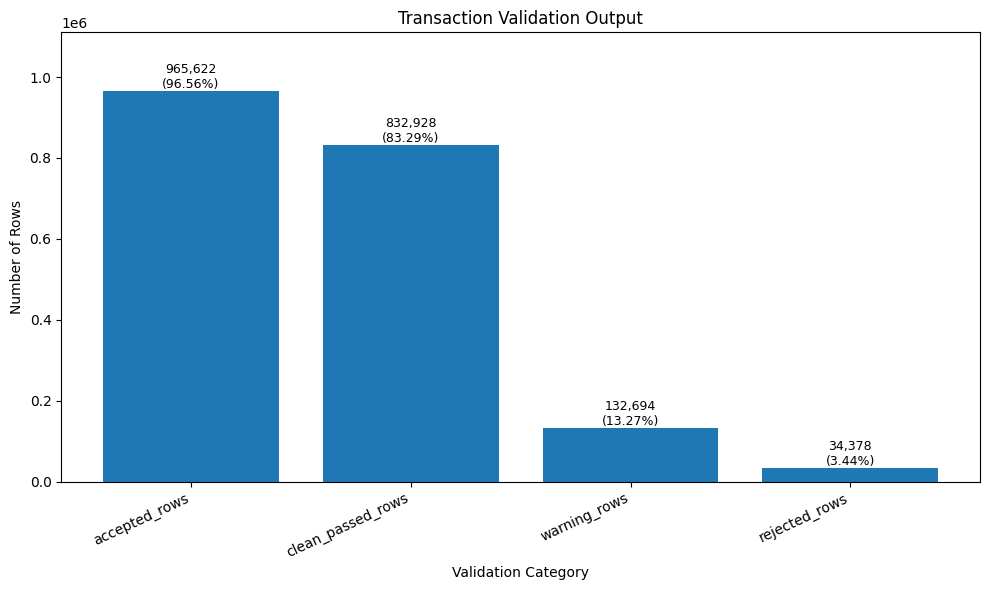

In [ ]:
plot_df = summary_pd[summary_pd["metric"].isin([
    "accepted_rows",
    "clean_passed_rows",
    "warning_rows",
    "rejected_rows",
])].copy()

# Keep the category order logical instead of whatever order comes from the dataframe
category_order = [
    "accepted_rows",
    "clean_passed_rows",
    "warning_rows",
    "rejected_rows",
]

plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=category_order,
    ordered=True
)

plot_df = plot_df.sort_values("metric")

# Add percentage of total rows for visual labels
plot_df["percentage_of_total"] = (
    plot_df["value"] / len(transactions_pd) * 100
).round(2)

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["metric"].astype(str), plot_df["value"])

plt.title("Transaction Validation Output")
plt.xlabel("Validation Category")
plt.ylabel("Number of Rows")
plt.xticks(rotation=25, ha="right")

# Add count + percentage on top of each bar
for bar, count, pct in zip(bars, plot_df["value"], plot_df["percentage_of_total"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Add some space above bars so labels do not get cut off
plt.ylim(0, plot_df["value"].max() * 1.15)

plt.tight_layout()
plt.savefig("results/charts/transaction_validation_output.png", dpi=300, bbox_inches="tight")
plt.show()

# Rule Violation Plot

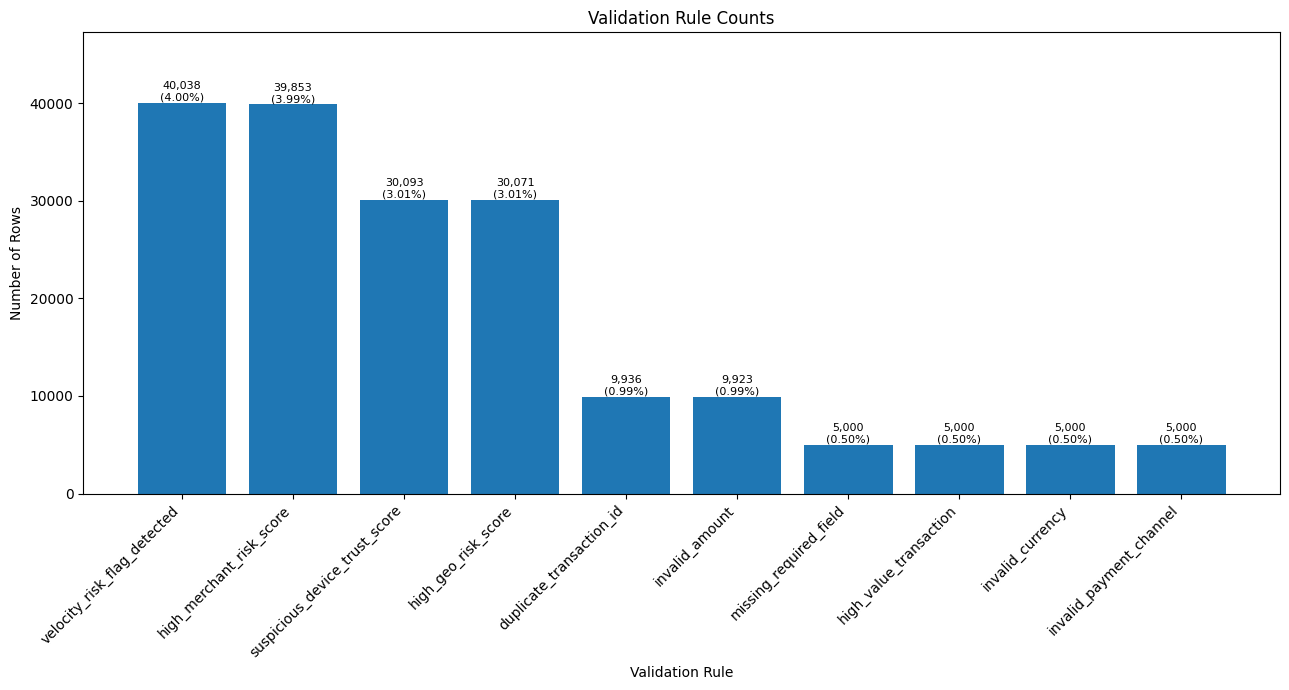

In [ ]:
rule_plot_df = summary_pd[summary_pd["metric"].isin(HARD_FAIL_COLUMNS + WARNING_COLUMNS)].copy()
rule_plot_df = rule_plot_df.sort_values("value", ascending=False)

# Add percentage of total rows for visual labels
rule_plot_df["percentage_of_total"] = (
    rule_plot_df["value"] / len(transactions_pd) * 100
).round(2)

plt.figure(figsize=(13, 7))
bars = plt.bar(rule_plot_df["metric"], rule_plot_df["value"])

plt.title("Validation Rule Counts")
plt.xlabel("Validation Rule")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45, ha="right")

# Add count + percentage on top of each rule bar
for bar, count, pct in zip(
    bars,
    rule_plot_df["value"],
    rule_plot_df["percentage_of_total"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count):,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add top padding so labels do not get cut off
plt.ylim(0, rule_plot_df["value"].max() * 1.18)

plt.tight_layout()
plt.savefig("results/charts/validation_rule_counts.png", dpi=300, bbox_inches="tight")
plt.show()

# Downstream AI

## Step 5: Show Downstream Output Quality Improvement

Many AI agents and analytics tools summarize data that has already been prepared for them.

If the input data is raw and unvalidated, the summary may include duplicate, invalid, or suspicious records without making that clear.

Here we create a simple text summary before and after validation to show why the validation layer matters.

#Summary Comparison

In [ ]:
def create_transaction_summary(label, row_count, total_amount, rejected_count=None, warning_count=None):
    if rejected_count is None:
        return (
            f"{label}: The transaction feed contains {row_count:,} rows with a total transaction amount "
            f"of ${total_amount:,.2f}. No validation layer was applied, so duplicate records, invalid values, "
            f"missing fields, and warning-level risk signals may still be included."
        )

    return (
        f"{label}: After validation, the accepted transaction feed contains {row_count:,} rows with a total "
        f"transaction amount of ${total_amount:,.2f}. The validation layer rejected {rejected_count:,} records "
        f"with hard failures and flagged {warning_count:,} records for review. This output is safer for downstream "
        f"analytics, compliance review, fraud monitoring, or AI-assisted workflows."
    )
without_validation_text = create_transaction_summary(
    "Without validation",
    len(transactions_pd),
    float(transactions_pd["transaction_amount"].sum()),
)

with_validation_text = create_transaction_summary(
    "With validation",
    len(accepted_pd),
    float(accepted_pd["transaction_amount"].sum()),
    len(rejected_pd),
    len(warnings_pd),
)

print(without_validation_text)
print()
print(with_validation_text)

Without validation: The transaction feed contains 1,000,000 rows with a total transaction amount of $327,391,412.50. No validation layer was applied, so duplicate records, invalid values, missing fields, and warning-level risk signals may still be included.

With validation: After validation, the accepted transaction feed contains 965,622 rows with a total transaction amount of $319,935,041.33. The validation layer rejected 34,378 records with hard failures and flagged 132,694 records for review. This output is safer for downstream analytics, compliance review, fraud monitoring, or AI-assisted workflows.


# Optional Extension


## Optional Extension: Connecting This to Real Systems
This notebook uses synthetic data by default so that the workflow is safe, reproducible, and easy to run in open-source environments.

In production, the same validation layer could be connected to:

- streaming transaction feeds,
- batch payment files,
- fraud event queues,
- compliance case systems,
- public financial metadata APIs,
- internal data lake tables.

For community notebooks, synthetic data is the default path. Any live API integration should be optional, license-safe, stable, and not required for the notebook to run.

# Conclusion

## Conclusion

In this notebook, we built a beginner-friendly financial transaction validation workflow using NVIDIA RAPIDS.

We generated synthetic financial transaction data, introduced realistic data quality and risk-style issues, and showed why processing raw data without validation can lead to unreliable downstream outputs. We then built a multi-layer validation layer that separates clean records, rejected records, and warning records.

RAPIDS cuDF allowed us to apply DataFrame-style validation rules using GPU acceleration. The CPU vs GPU comparison provides supporting evidence that this type of workflow can scale to larger transaction volumes.

The most important outcome is not just speed. The most important outcome is better output quality: cleaner data, clearer rule violations, separated warning records, and safer downstream analytics or AI-assisted workflows.

You can adapt this validation layer for your own AI agents, fraud monitoring systems, compliance workflows, payment pipelines, financial dashboards, or transaction quality checks.

In [ ]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("results/charts", exist_ok=True)

# Save summary CSV files
raw_summary.to_csv("results/raw_summary.csv", index=False)
summary_pd.to_csv("results/validation_summary.csv", index=False)
comparison_summary.to_csv("results/with_vs_without_validation.csv", index=False)
runtime_comparison.to_csv("results/runtime_comparison.csv", index=False)

# Save sample transaction outputs
accepted_pd.head(10000).to_csv("results/accepted_transactions_sample.csv", index=False)
clean_passed_pd.head(10000).to_csv("results/clean_passed_transactions_sample.csv", index=False)
warnings_pd.head(10000).to_csv("results/warning_transactions_sample.csv", index=False)
rejected_pd.head(10000).to_csv("results/rejected_transactions_sample.csv", index=False)

print("CSV output files saved to results/")

CSV output files saved to results/
